# 🏡 House Price Prediction using Linear Regression

## Objective

Build a machine learning model to predict house prices using Linear Regression. The project includes Exploratory Data Analysis (EDA), data preprocessing, feature engineering, model training, evaluation, and interpretation.

In [14]:
# ===========================================
# Import Libraries
# ===========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# Dataset Loading

Load the housing dataset and inspect its structure.

In [15]:
df = pd.read_csv("data.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [16]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (4600, 18)


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [18]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


# Missing Value Analysis

Check missing values present in each feature.

In [19]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

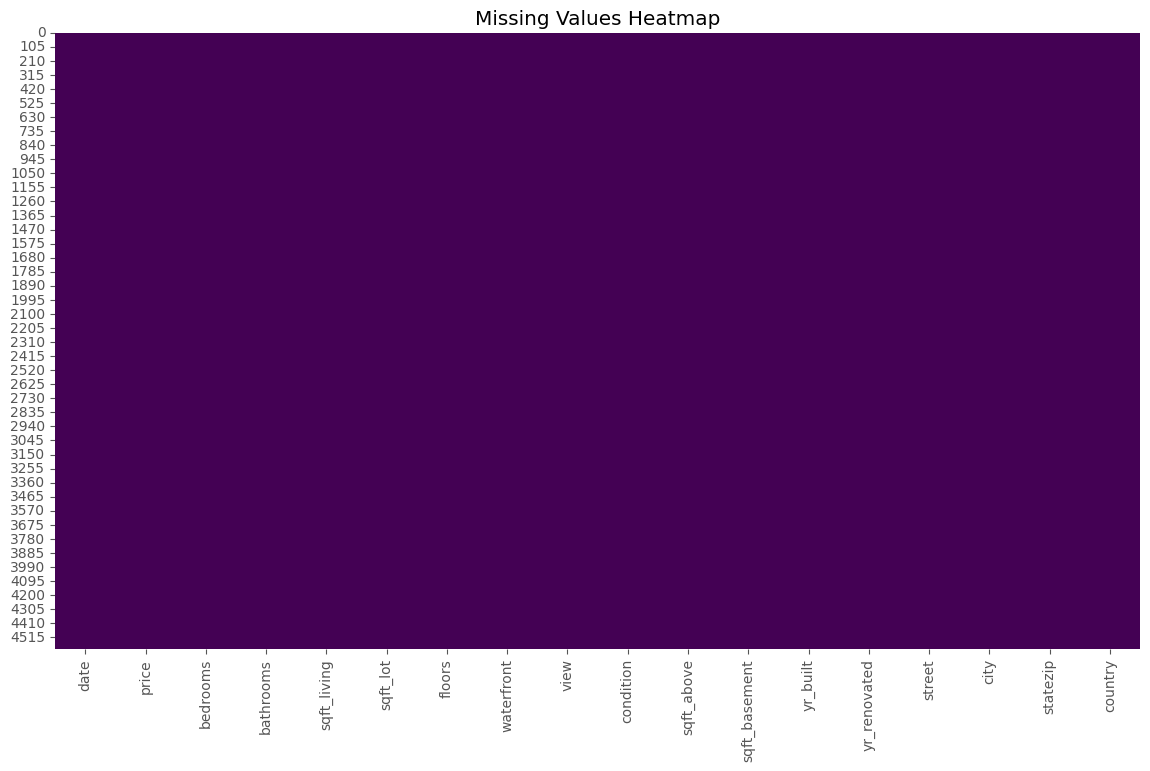

In [20]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [22]:
print(df.columns.tolist())

['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


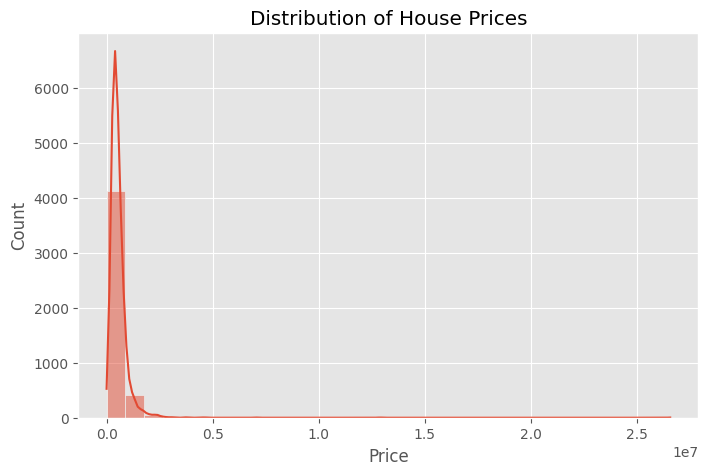

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

# Feature Selection

The following features are expected to influence house prices:

- Bedrooms
- Bathrooms
- Living Area (sqft_living)
- Lot Area (sqft_lot)
- Floors
- Waterfront
- View
- Condition
- Year Built
- Year Renovated
- City

These variables describe the size, quality, location, and amenities of a property, making them important predictors of house prices.

In [25]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

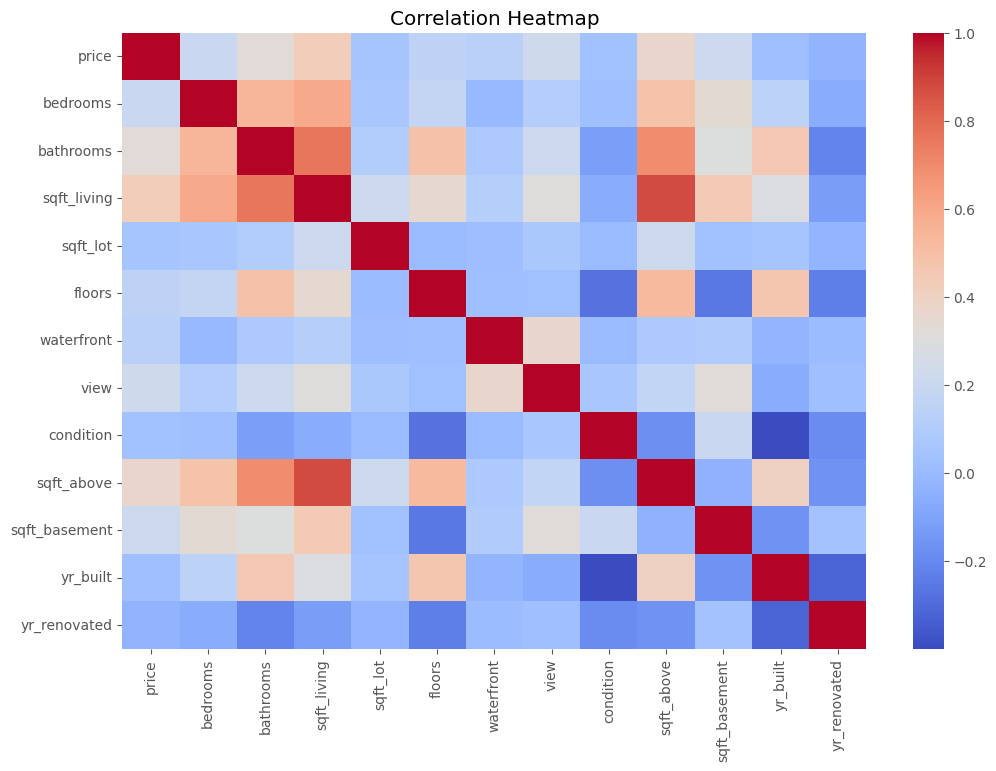

In [26]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
categorical_columns = [
    "street",
    "city",
    "statezip",
    "country"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [28]:
X = df.drop(["price", "date"], axis=1)

y = df["price"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import numpy as np

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R² Score :", r2)

Mean Squared Error : 4584212196634.328
Root Mean Squared Error : 2141077.344851028
R² Score : -3.495002841549117


# Actual vs Predicted House Prices

This visualization compares the actual house prices with the predicted prices generated by the Linear Regression model. Points closer to the diagonal line indicate better prediction accuracy.

Images folder created successfully!


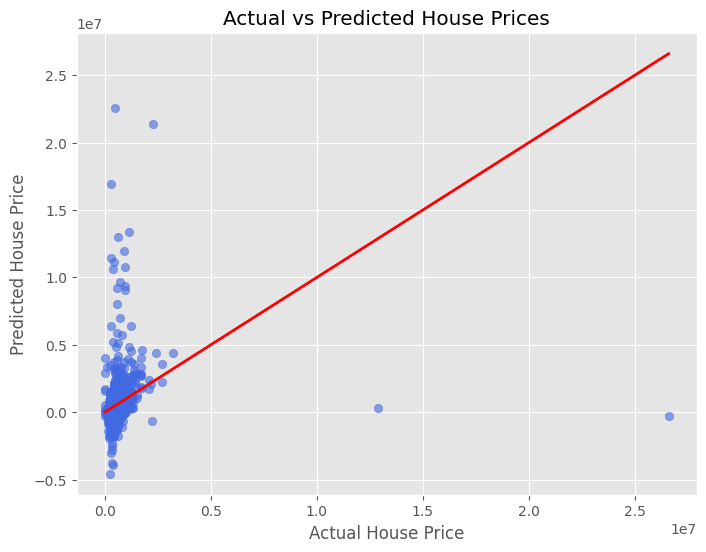

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.6, color="royalblue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

import os

# Create images folder if it doesn't exist
os.makedirs("images", exist_ok=True)

print("Images folder created successfully!")

plt.savefig("images/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Residual Plot

Residuals represent the difference between actual and predicted house prices.

A well-performing Linear Regression model should produce residuals that are randomly scattered around zero without any visible pattern.

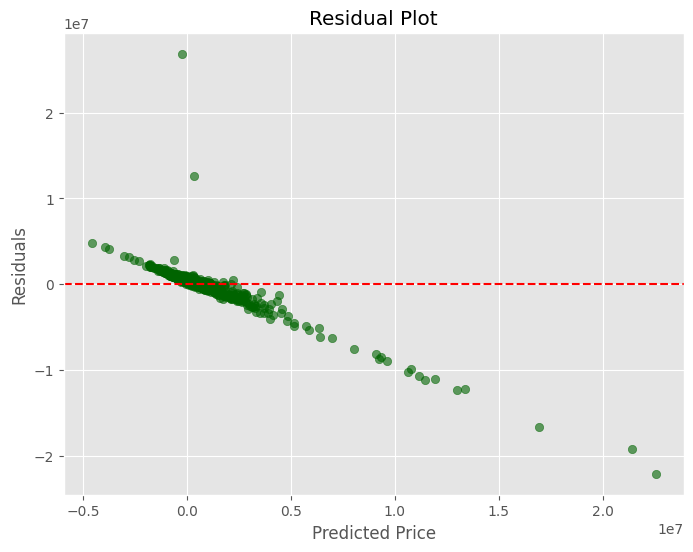

In [34]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.6,
    color="darkgreen"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.savefig("images/residual_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Coefficient Analysis

Linear Regression coefficients indicate how much each feature contributes to the predicted house price.

Positive coefficients increase the predicted price, while negative coefficients decrease it.

In [35]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient
1412,street_1783 Loraine St,4.731347e+06
2836,street_3402 261st Pl SE,4.611247e+06
851,street_1419 Farrelly St,4.523528e+06
3912,street_710 Victor St,4.454723e+06
4051,street_7615 SW 257th St,4.407361e+06
367,street_1168 Semanski St,4.385839e+06
2649,street_31103 SE 85th Pl,4.359384e+06
3481,street_506 Harmony Ln,4.353023e+06
3232,street_4309 327th Pl SE,4.221065e+06
2779,street_32901 SE 43rd St,4.183291e+06


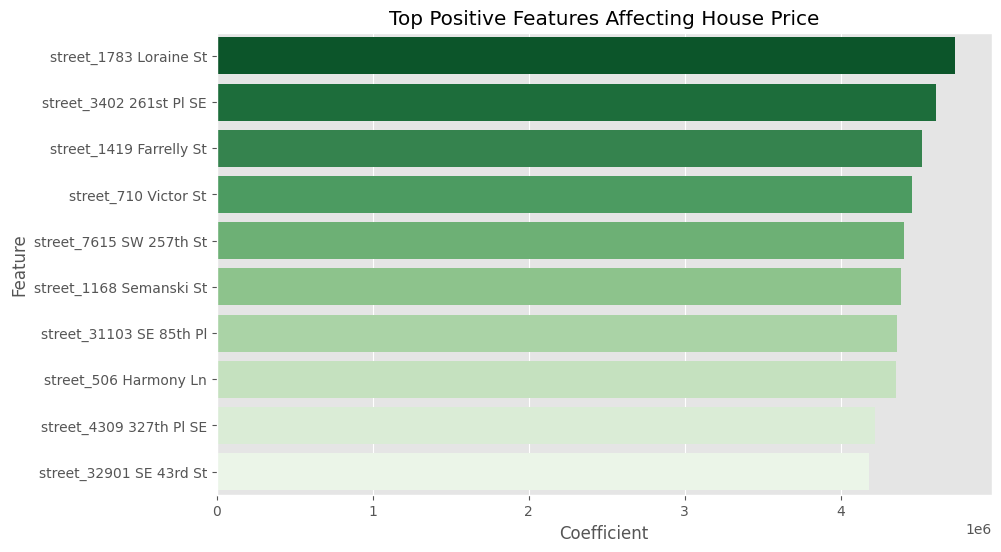

In [36]:
plt.figure(figsize=(10,6))

top_positive = coefficients.head(10)

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature",
    palette="Greens_r"
)

plt.title("Top Positive Features Affecting House Price")

plt.savefig("images/top_positive_features.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

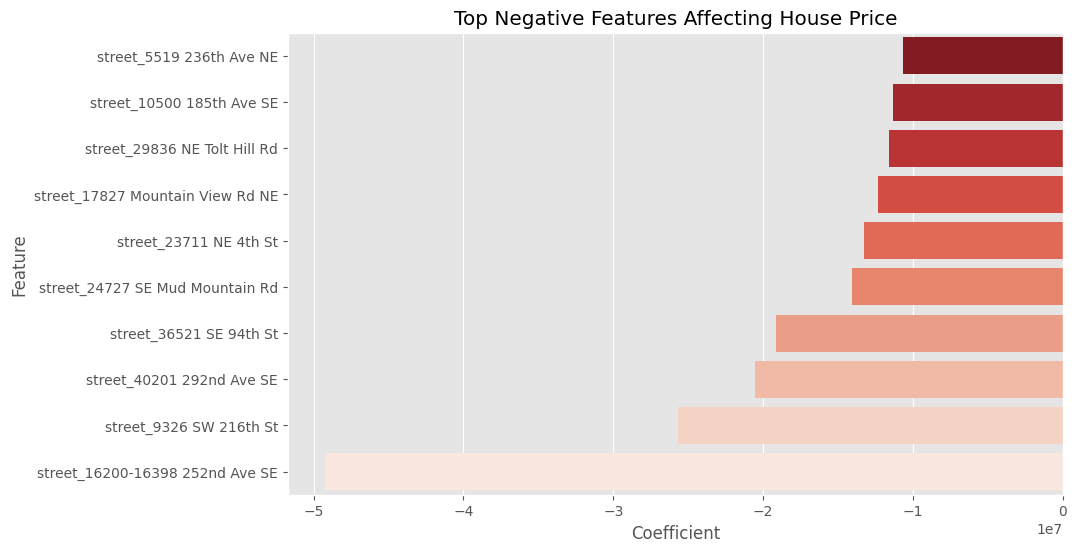

In [37]:
plt.figure(figsize=(10,6))

top_negative = coefficients.tail(10)

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature",
    palette="Reds_r"
)

plt.title("Top Negative Features Affecting House Price")

plt.savefig("images/top_negative_features.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [38]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge R² Score :", r2_score(y_test, ridge_pred))

Ridge R² Score : 0.054572247375513694


In [39]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R² Score :", r2_score(y_test, lasso_pred))

Lasso R² Score : 0.03201038980842508


In [40]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "R² Score": [
        r2_score(y_test, predictions),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

comparison

,Model,R² Score
0,Linear Regression,-3.495003
1,Ridge Regression,0.054572
2,Lasso Regression,0.032010


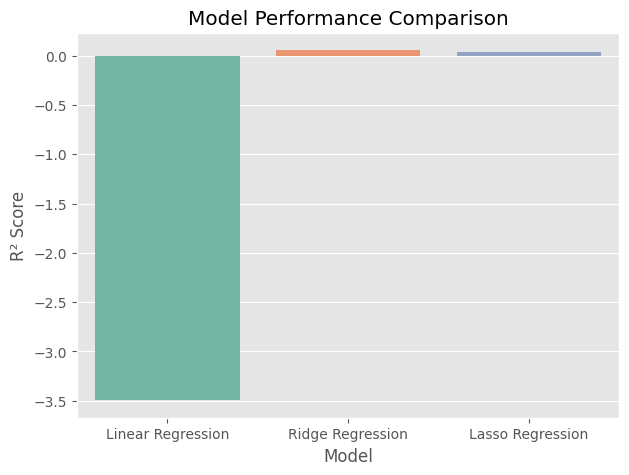

In [41]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R² Score",
    palette="Set2"
)

plt.title("Model Performance Comparison")

plt.savefig("images/model_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Conclusion

This project successfully developed a Linear Regression model to predict house prices based on property characteristics.

## Key Findings

- Data preprocessing improved data quality.
- One-Hot Encoding enabled the use of categorical features.
- Correlation analysis identified the strongest predictors.
- Linear Regression provided a solid baseline model.
- Ridge and Lasso Regression were evaluated for comparison.
- Model performance was measured using MSE, RMSE, and R² Score.

## Real-World Applications

- Real estate price estimation
- Property valuation
- Investment analysis
- Housing market forecasting
- Real estate recommendation systems